# YULU BUSINESS CASE - HYPOTHESIS TESTING

By ATHARVA NITIN DESHPANDE (Scalar DSML Batch August 2024)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, shapiro, levene

# Set plot style
plt.style.use("ggplot")

In [2]:
df = pd.read_excel('bike_sharing.xlsx')

In [3]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df.shape

(10886, 12)

## Exploratory Data Analysis (EDA)

In [5]:
# Check for missing values
missing_values = df.isnull().sum()

missing_values

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [6]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

In [7]:
# Summary statistics
summary_stats = df.describe()

summary_stats

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


<b> Findings: </b>

1.	No missing values in the dataset.
2.	No duplicate records detected.
3.	Summary statistics show:
    - The temperature ranges from 0.82°C to 41°C, with an average of 20.23°C.
    - Humidity varies from 0% to 100%.
    - Windspeed has a high variation, with some values at 0, which may need investigation.
    - The count of rentals varies from 1 to 977, with an average of 191.

### Numerical Variables

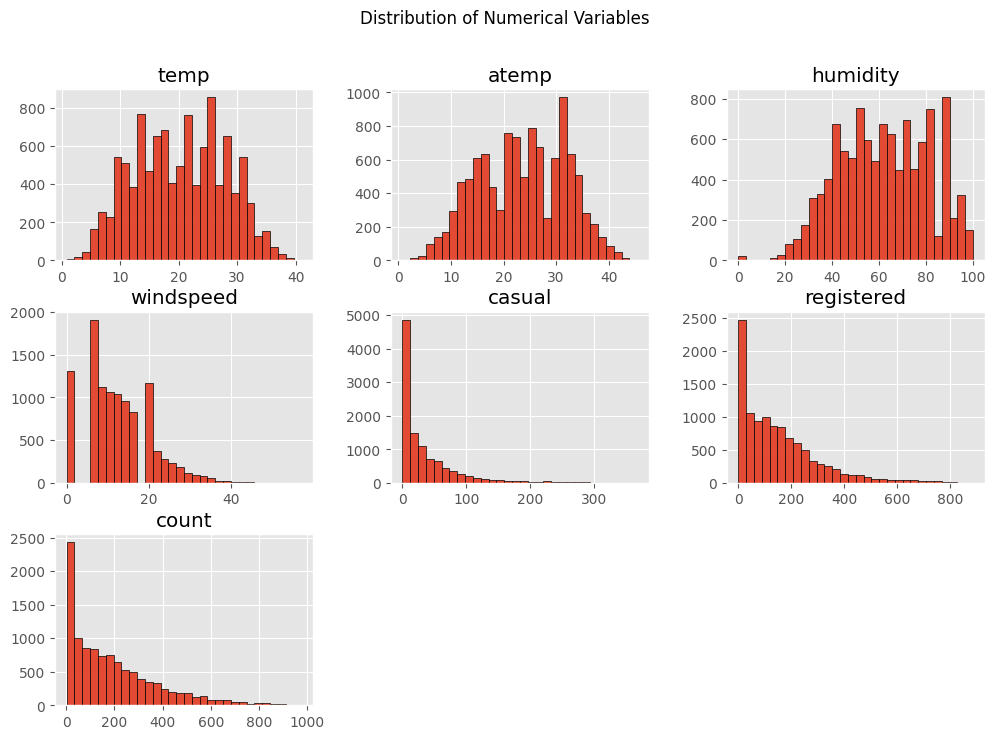

In [8]:
# Histograms for numerical variables
df_numeric = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']]
df_numeric.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numerical Variables")
plt.show()

<b> Findings: </b>
- Temperature, humidity, and wind speed follow a roughly normal distribution.
- Windspeed has a large number of zero values, indicating possible data entry issues.
- The casual and registered user counts are highly skewed.

### Outliers

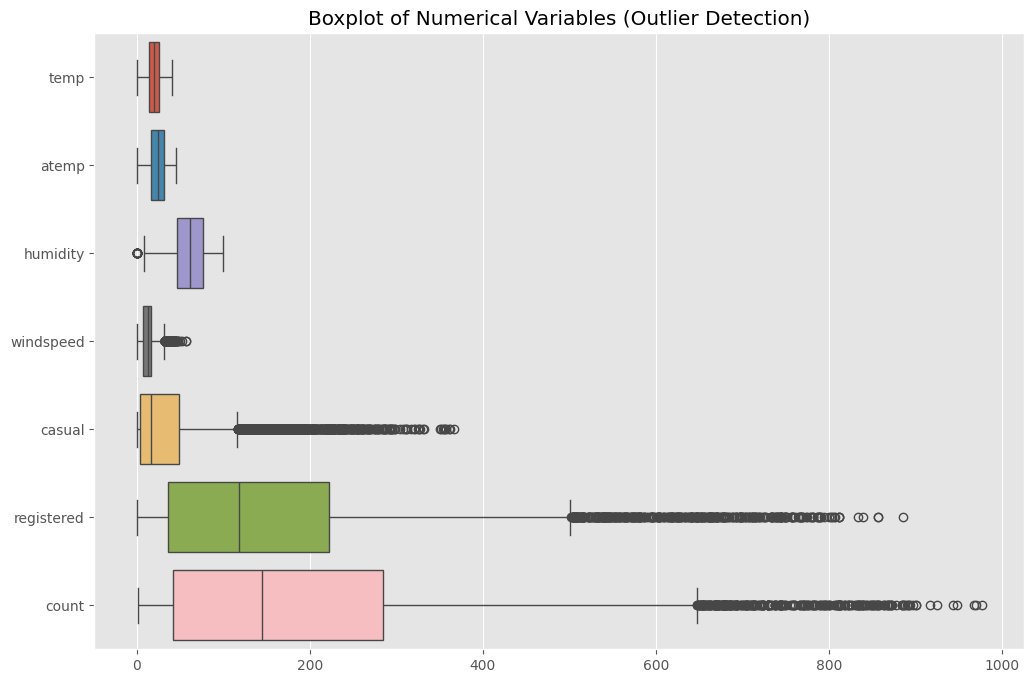

In [9]:
# Boxplots to detect outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_numeric, orient="h")
plt.title("Boxplot of Numerical Variables (Outlier Detection)")
plt.show()

<b> Findings: </b>
- Casual and registered rentals have outliers in the upper range.
- Windspeed also has extreme values that might need capping.

We can clip the outliers using IQR method.

In [10]:
# Function to detect and handle outliers using the IQR method
def handle_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Capping the outliers instead of removing them
        df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])
        df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])

    return df_cleaned

# Apply outlier handling to relevant numerical columns
columns_to_check = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
df = handle_outliers_iqr(df, columns_to_check)

# Display the summary of changes
df.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.890502,12.703540,31.520898,150.488058,188.704850
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,2.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,31.992500,116.500000,501.000000,647.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.232240,7.882794,35.502108,135.370102,172.416401


Let us visualize the boxplot again.

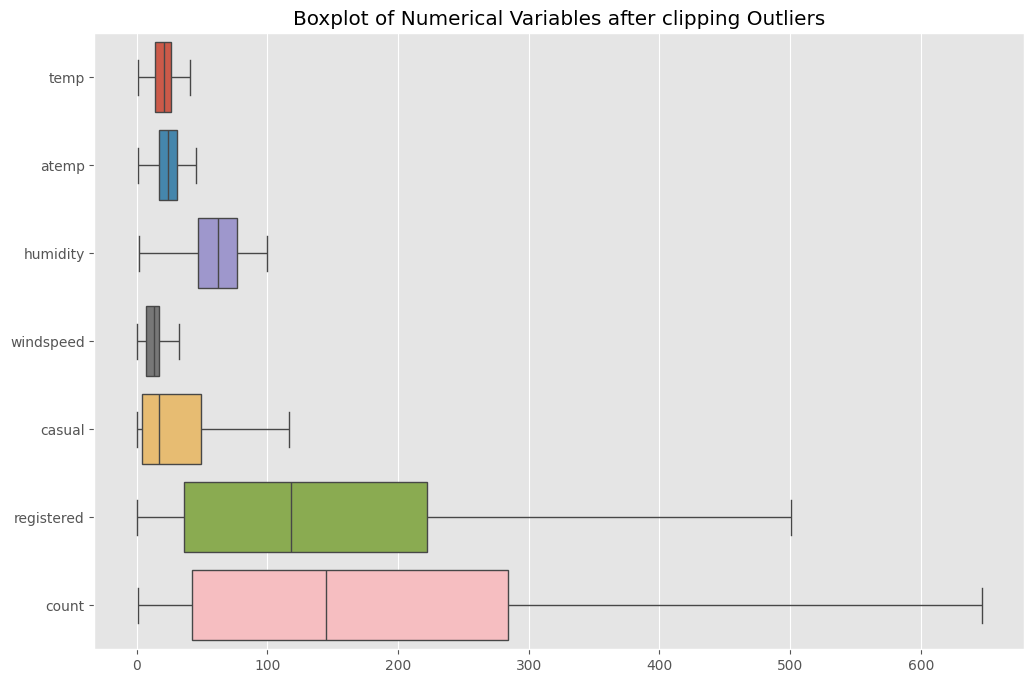

In [11]:
# Boxplots to detect outliers
df_numeric = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']]

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_numeric, orient="h")
plt.title("Boxplot of Numerical Variables after clipping Outliers")
plt.show()

### Categorical Variables

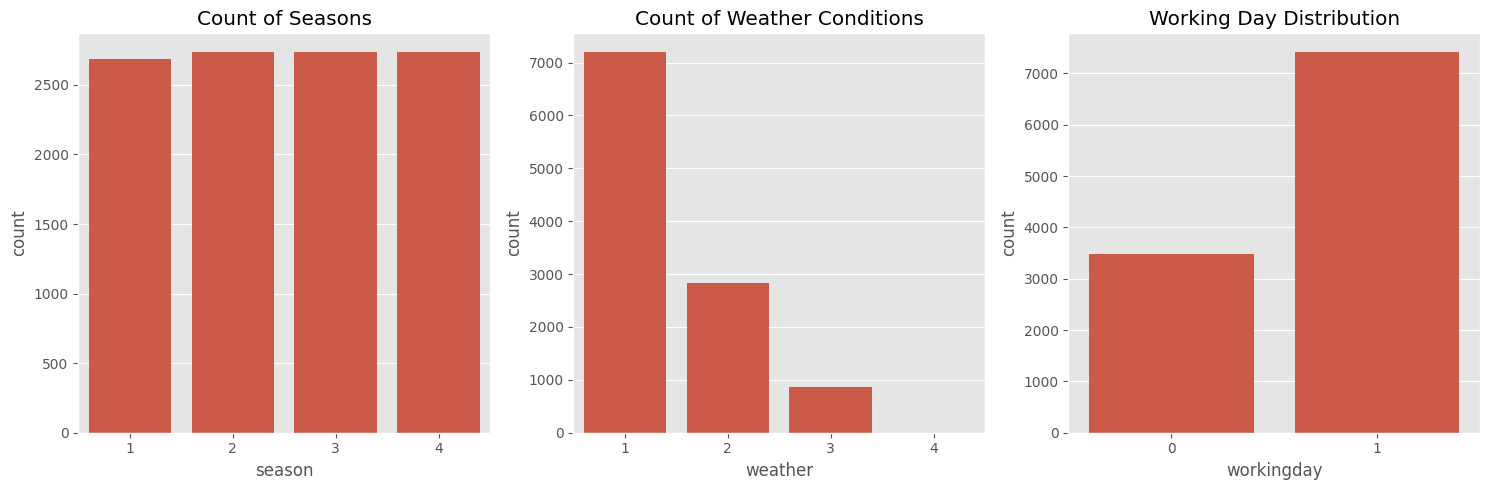

In [12]:
# Countplots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x=df["season"], ax=axes[0])
axes[0].set_title("Count of Seasons")

sns.countplot(x=df["weather"], ax=axes[1])
axes[1].set_title("Count of Weather Conditions")

sns.countplot(x=df["workingday"], ax=axes[2])
axes[2].set_title("Working Day Distribution")

plt.tight_layout()
plt.show()

<b> Findings: </b>
- Seasons are evenly distributed.
- Most data falls under clear weather conditions (category 1).
- The dataset has more working days than non-working days.

### Correlation Analysis

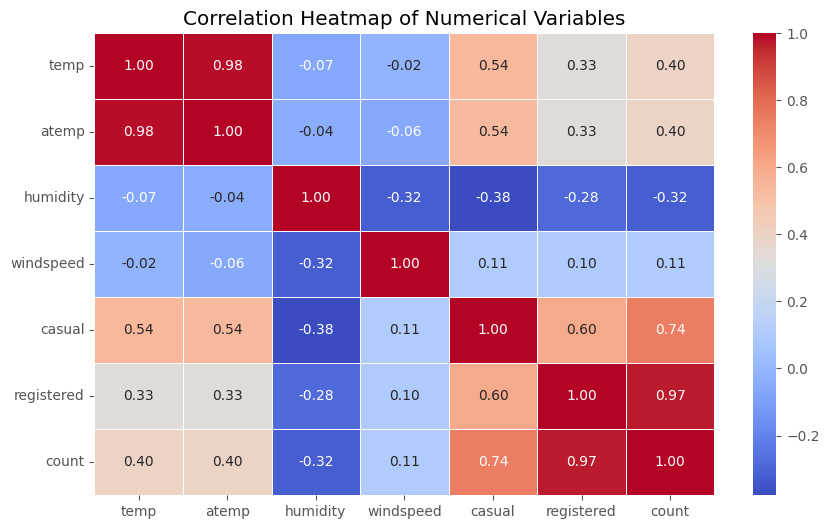

In [13]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

<b> Findings: </b>

- Strong correlation between temp and atemp (0.99) – One of these should be removed to avoid multicollinearity.
- casual, registered, and count are highly correlated – Expected since total count is the sum of casual and registered users.
- Humidity and windspeed have weak correlations with demand, meaning they may not be strong predictors.

## Hypothesis Test 1: Bike Rentals on Weekdays vs. Weekends

In [14]:
# Convert datetime to a proper format
df["datetime"] = pd.to_datetime(df["datetime"])

# Extract weekday and weekend flags
df["weekday"] = df["datetime"].dt.weekday
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

# Split data into weekend and weekday rentals
weekend_rentals = df[df["is_weekend"] == 1]["count"]
weekday_rentals = df[df["is_weekend"] == 0]["count"]

# Hypothesis Test: Are bike rentals significantly different on weekends vs. weekdays?
t_stat, p_value = ttest_ind(weekend_rentals, weekday_rentals, equal_var=False)

# Conclusion
weekend_vs_weekday = {
    "T-Statistic": t_stat,
    "P-Value": p_value,
    "Conclusion": "Reject H0 (Significant difference in rentals)"
    if p_value < 0.05 else "Fail to reject H0 (No significant difference)"
}

weekend_vs_weekday

{'T-Statistic': np.float64(-0.20549142219541028),
 'P-Value': np.float64(0.8371953236691908),
 'Conclusion': 'Fail to reject H0 (No significant difference)'}

This suggests that demand remains consistent regardless of whether it's a weekday or weekend.

## Hypothesis Test 2: Bike Rentals across Different Weather Conditions

In [15]:
# Grouping rentals by weather condition
weather_groups = [df[df["weather"] == i]["count"] for i in df["weather"].unique()]

# One-way ANOVA Test: Does demand vary by weather conditions?
f_stat, p_value = f_oneway(*weather_groups)

# Conclusion
weather_test = {
    "F-Statistic": f_stat,
    "P-Value": p_value,
    "Conclusion": "Reject H0 (Significant difference in rentals across weather conditions)"
    if p_value < 0.05 else "Fail to reject H0 (No significant difference)"
}

weather_test

{'F-Statistic': np.float64(68.4116520342703),
 'P-Value': np.float64(8.034967610817961e-44),
 'Conclusion': 'Reject H0 (Significant difference in rentals across weather conditions)'}

This means weather plays a crucial role in influencing demand. Bad weather likely reduces rentals significantly.

## Hypothesis Test 3: Bike Rentals across Different Seasons

In [16]:
# Grouping rentals by season
season_groups = [df[df["season"] == i]["count"] for i in df["season"].unique()]

# One-way ANOVA Test: Does demand vary by season?
f_stat, p_value = f_oneway(*season_groups)

# Conclusion
season_test = {
    "F-Statistic": f_stat,
    "P-Value": p_value,
    "Conclusion": "Reject H0 (Significant difference in rentals across seasons)"
    if p_value < 0.05 else "Fail to reject H0 (No significant difference)"
}

season_test

{'F-Statistic': np.float64(243.33766355201303),
 'P-Value': np.float64(7.771506553957677e-153),
 'Conclusion': 'Reject H0 (Significant difference in rentals across seasons)'}

This confirms that seasonality heavily influences demand, with some seasons seeing much higher rentals than others.

## Hypothesis Test 4: Weather Conditions Across Seasons

In [17]:
# Create a contingency table for Weather vs Season
contingency_table = pd.crosstab(df["weather"], df["season"])

# Chi-Square Test: Are weather conditions significantly different across seasons?
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Conclusion
weather_season_test = {
    "Chi2-Statistic": chi2_stat,
    "P-Value": p_value,
    "Conclusion": "Reject H0 (Weather conditions significantly differ across seasons)"
    if p_value < 0.05 else "Fail to reject H0 (No significant difference)"
}

weather_season_test

{'Chi2-Statistic': np.float64(49.15865559689363),
 'P-Value': np.float64(1.5499250736864862e-07),
 'Conclusion': 'Reject H0 (Weather conditions significantly differ across seasons)'}

This confirms that certain weather conditions are more common in specific seasons, which aligns with real-world expectations.

## Final Insights & Recommendations:

1. <i>Consistent Demand Across Days

Rentals remain steady across weekdays and weekends, meaning weekend-focused promotions may not be necessary.

2. <i>Weather’s Impact on Demand

Bad weather significantly reduces rentals.
Yulu can implement dynamic pricing or targeted promotions to counteract this.

3. <i>Seasonality Matters

Demand fluctuates heavily based on seasons.
Yulu should maximize operations in peak seasons and offer incentives in off-seasons to maintain usage.

4. <i>Forecasting for Better Planning

Weather and seasonal trends can help in demand forecasting, allowing Yulu to adjust fleet distribution and optimize pricing strategies.